In [69]:
import os
import zarr
import numpy as np
import matplotlib.pyplot as plt
import trackpy as tp

import sys

sys.path.append(os.path.abspath(".."))
plt.style.use('../libs/my_style.mplstyle')

#mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = "/mnt/e/Sasaki/MTsingleBeads"

folder = os.path.join(mypass, '20260122/exp001') 

path = os.path.join(folder, 'MTs_red.zarr')

TIME_SHIFT = 1

MTs = zarr.open(path, mode='r')
# 1. データを読み込む（型変換せず、まずは元の型のまま）
raw_data = MTs[:] 

# 2. 結果格納用の配列を先に確保（uint8）
diff = np.zeros(raw_data[TIME_SHIFT:].shape, dtype=np.uint8)

# 3. 計算
# np.subtract の where 引数を使うことで、
# 「引いた結果が正の時だけ書き込む」という処理を1パスで実行可能
_=np.subtract(raw_data[TIME_SHIFT:], raw_data[:-1*TIME_SHIFT], out=diff, where=(raw_data[TIME_SHIFT:] > raw_data[:-TIME_SHIFT]))

Text(0.5, 1.0, 'Histogram of intensity difference between frames')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

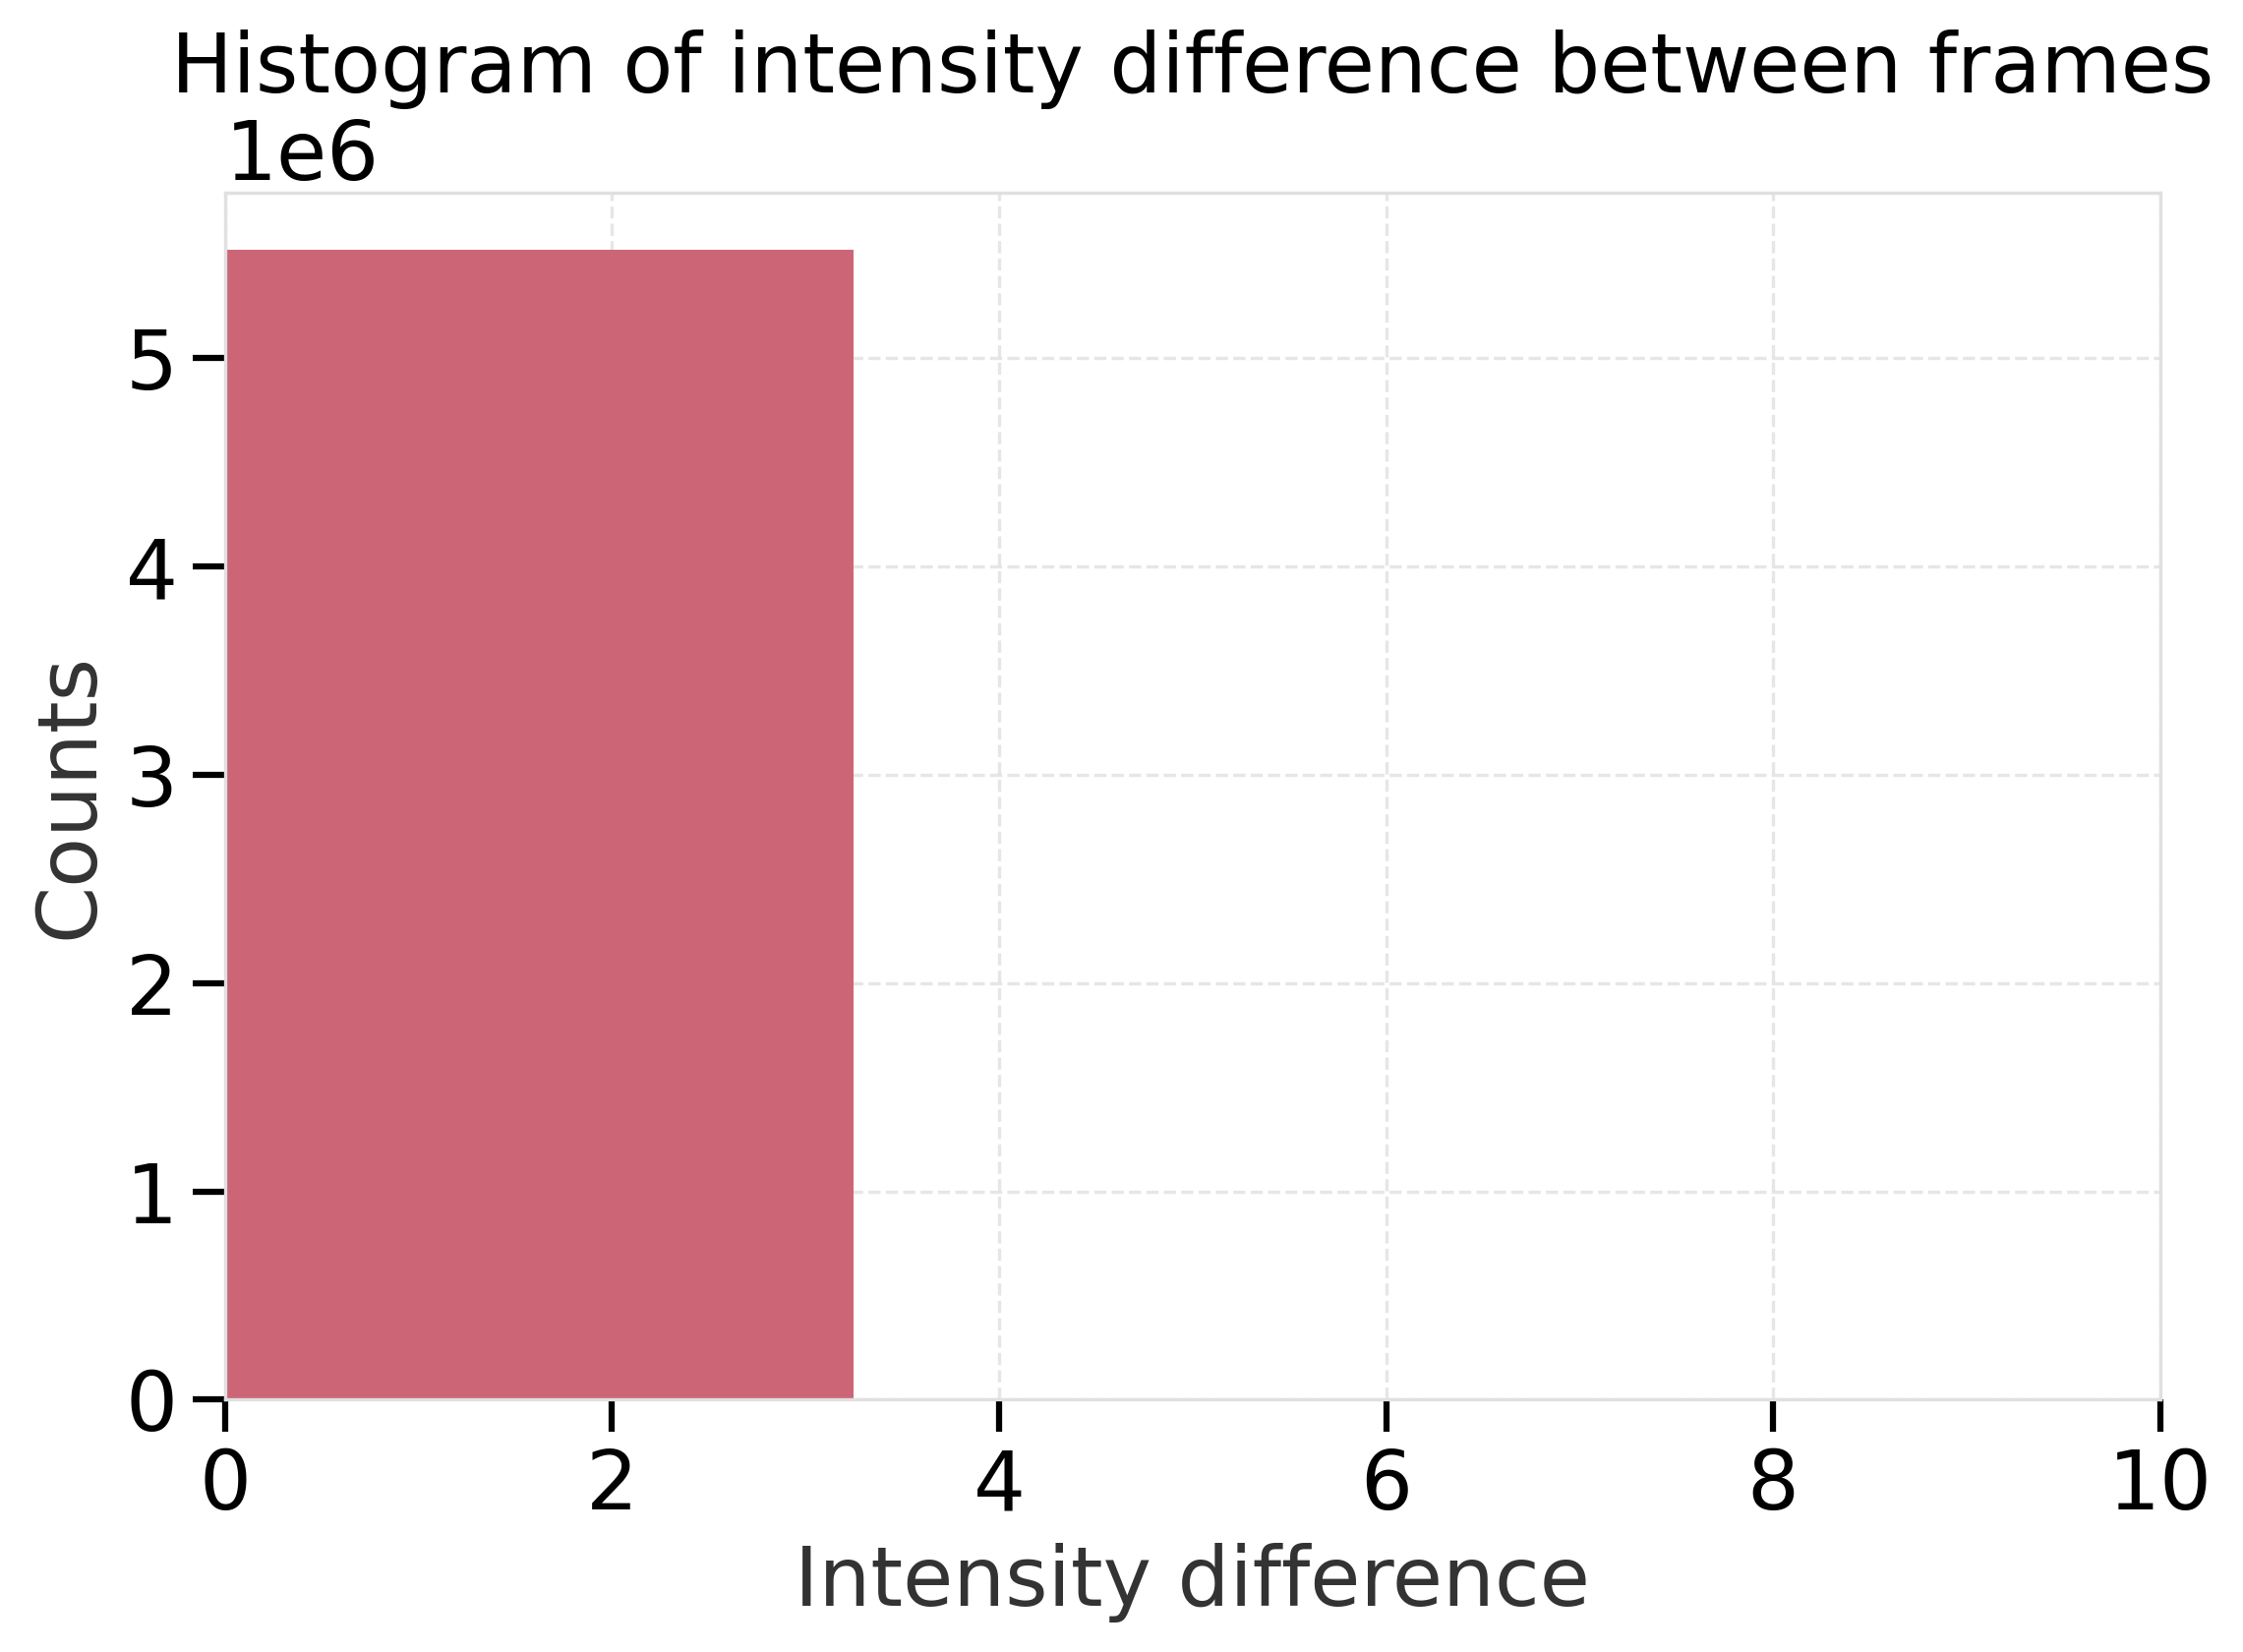

In [70]:
data_for_hist=diff[0].reshape(-1)
bins = np.histogram_bin_edges(data_for_hist, bins = 'sturges')
_=plt.hist(diff[0].reshape(-1), bins =bins)
plt.xlim(0,10)
#plt.yscale('log')
plt.xlabel('Intensity difference')
plt.ylabel('Counts')
plt.title('Histogram of intensity difference between frames')

In [71]:
velocity = 0.7  # um/s
scale = 0.11 # um/pixel
time_interval = 4.0  # s
growth_per_frame = int(velocity * time_interval * TIME_SHIFT / scale)  # pixels/frame

velocity_per_frame = int(velocity * time_interval/ scale)

if growth_per_frame % 2 ==0:
    growth_per_frame = growth_per_frame + 1

print(f'Expected growth per frame: {growth_per_frame:.2f} pixels/frame')

Expected growth per frame: 25.00 pixels/frame


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

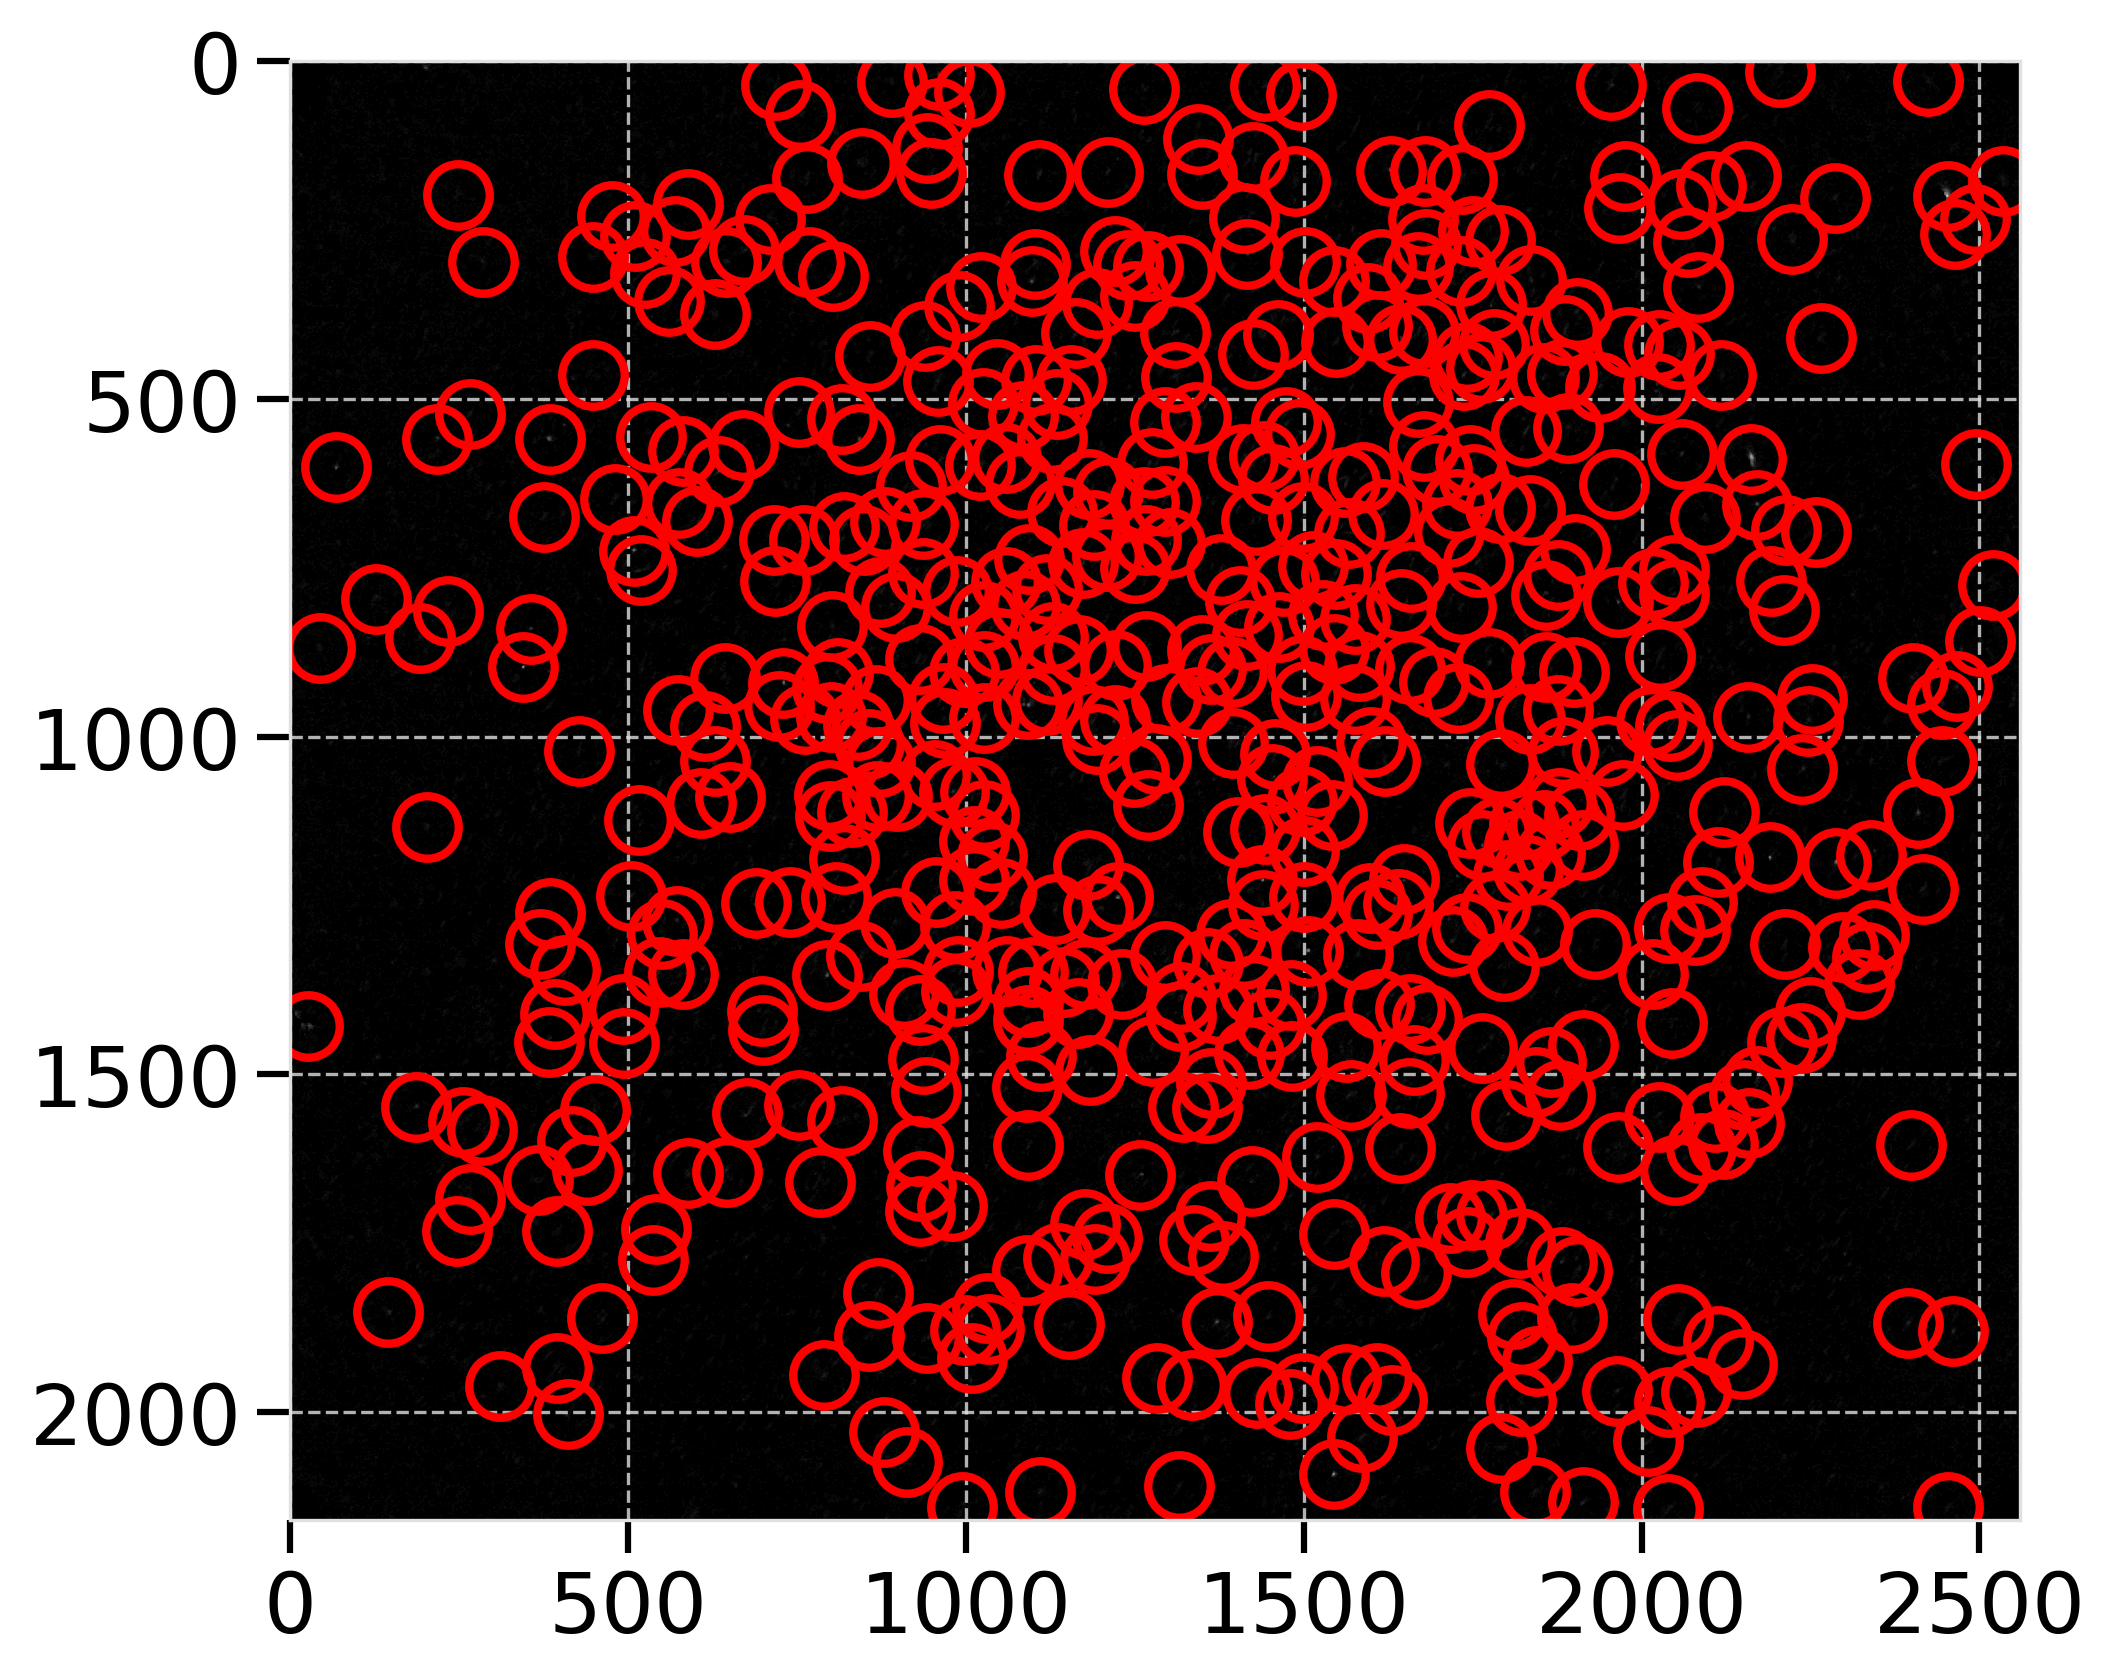

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

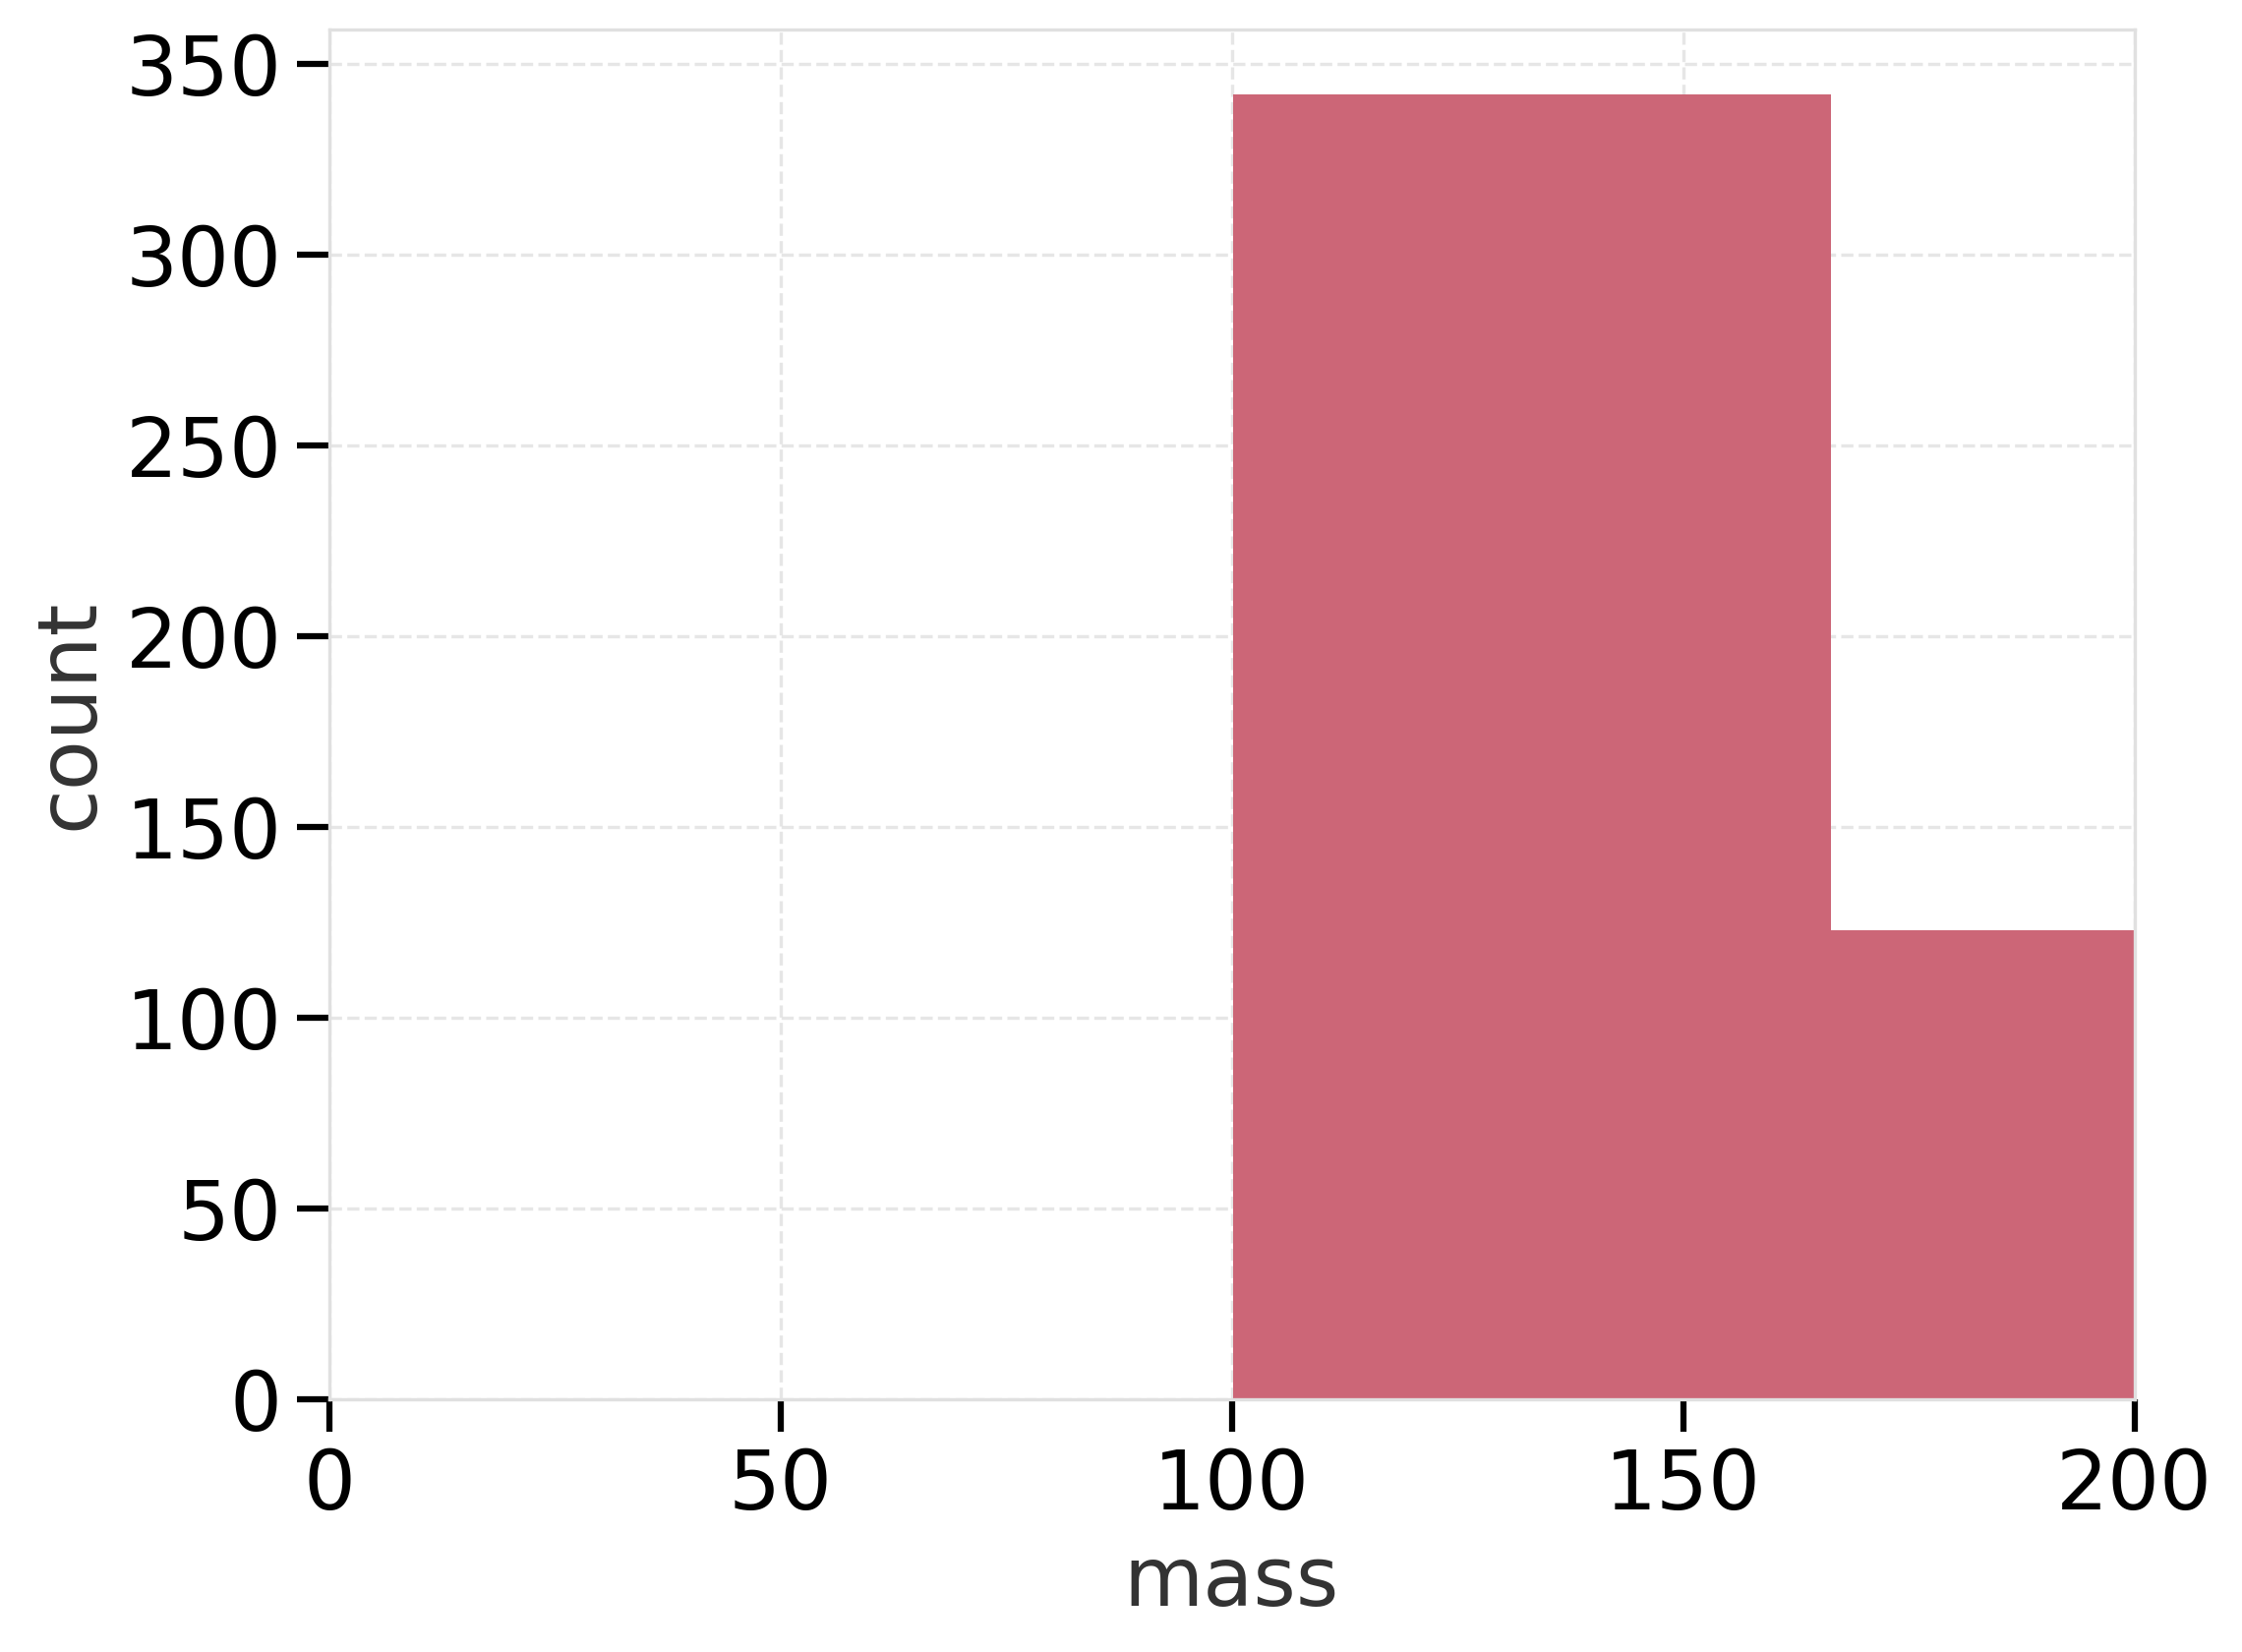

In [76]:
minmass = 100
threshold = 1
noise_size = 1

t = 90

f = tp.locate(diff[t], growth_per_frame, minmass = minmass, threshold=threshold , noise_size=noise_size)
tp.annotate(f, diff[t])

fig, ax = plt.subplots()
ax.hist(f['mass'], bins=20)
# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count', xlim=(0, 200));

#tp.subpx_bias(f)

In [77]:
f = tp.batch(diff, growth_per_frame, minmass = minmass, threshold=threshold, noise_size=noise_size)

Frame 499: 34 features


In [78]:
tracks = tp.link(f, velocity_per_frame)
t1 = tp.filter_stubs(tracks, 10)

Frame 499: 34 trajectories present.


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

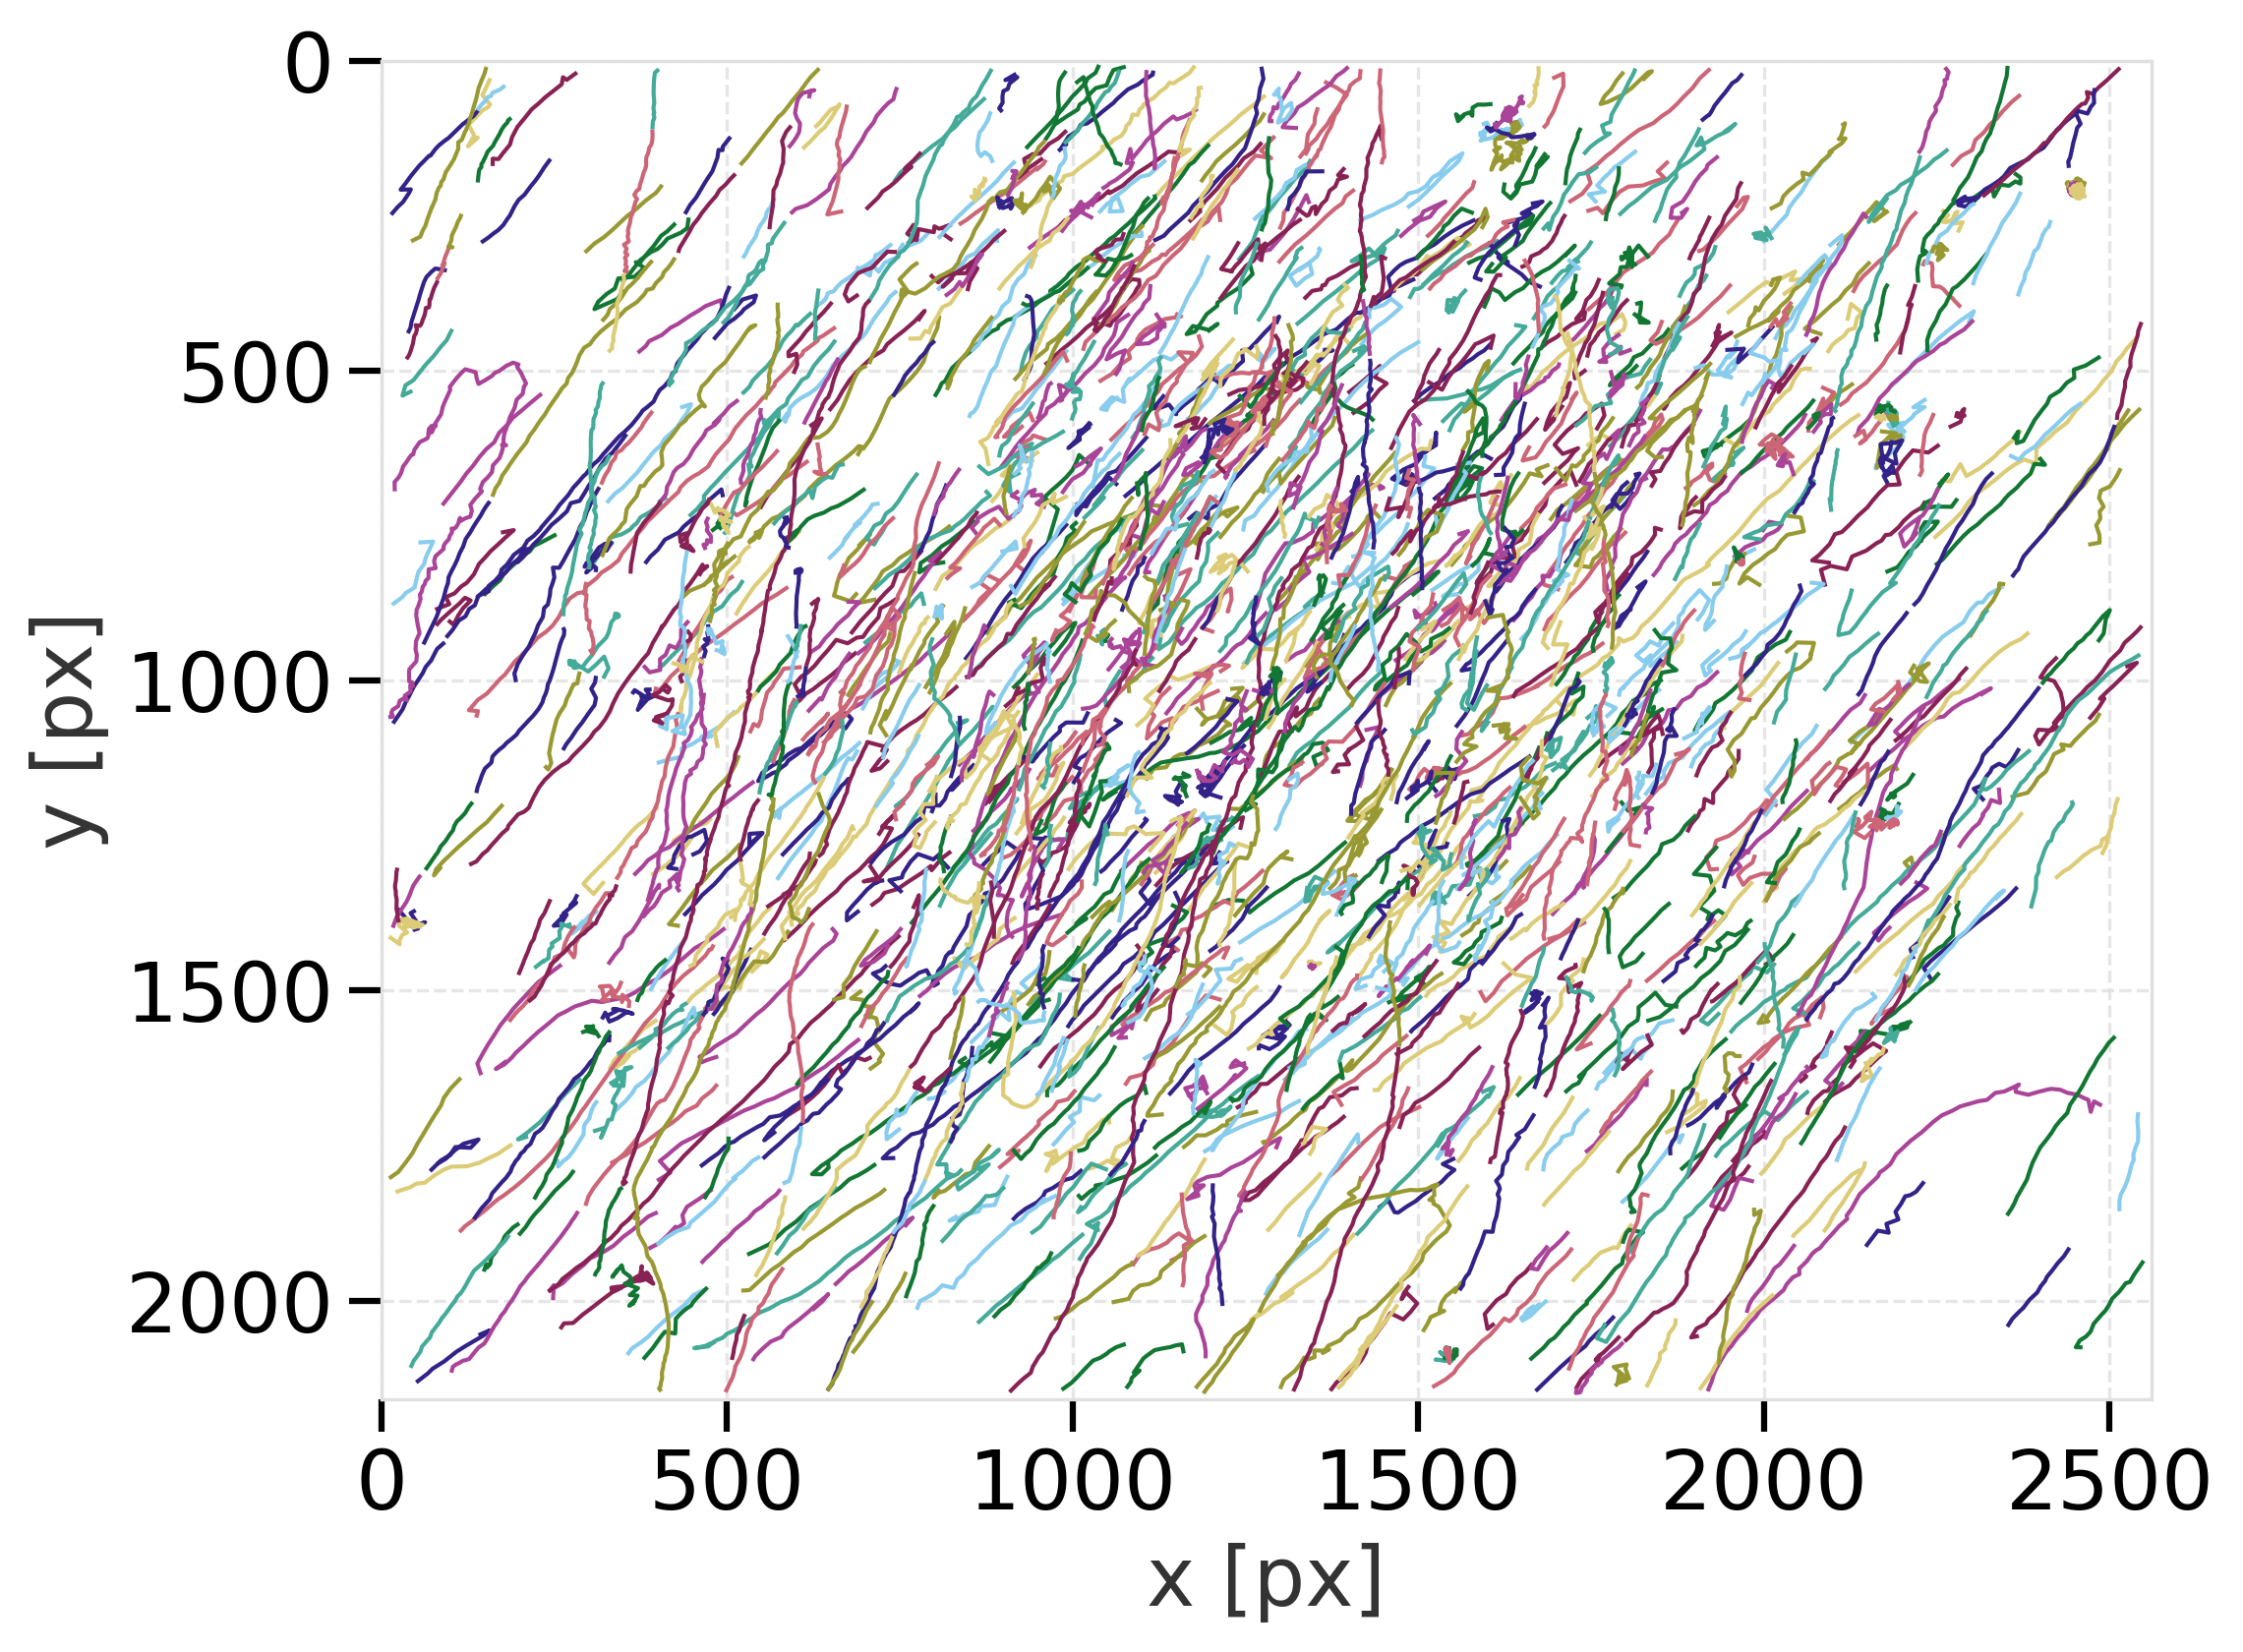

In [79]:
plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(t1);

/tmp/ipykernel_2020/956435003.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not fo

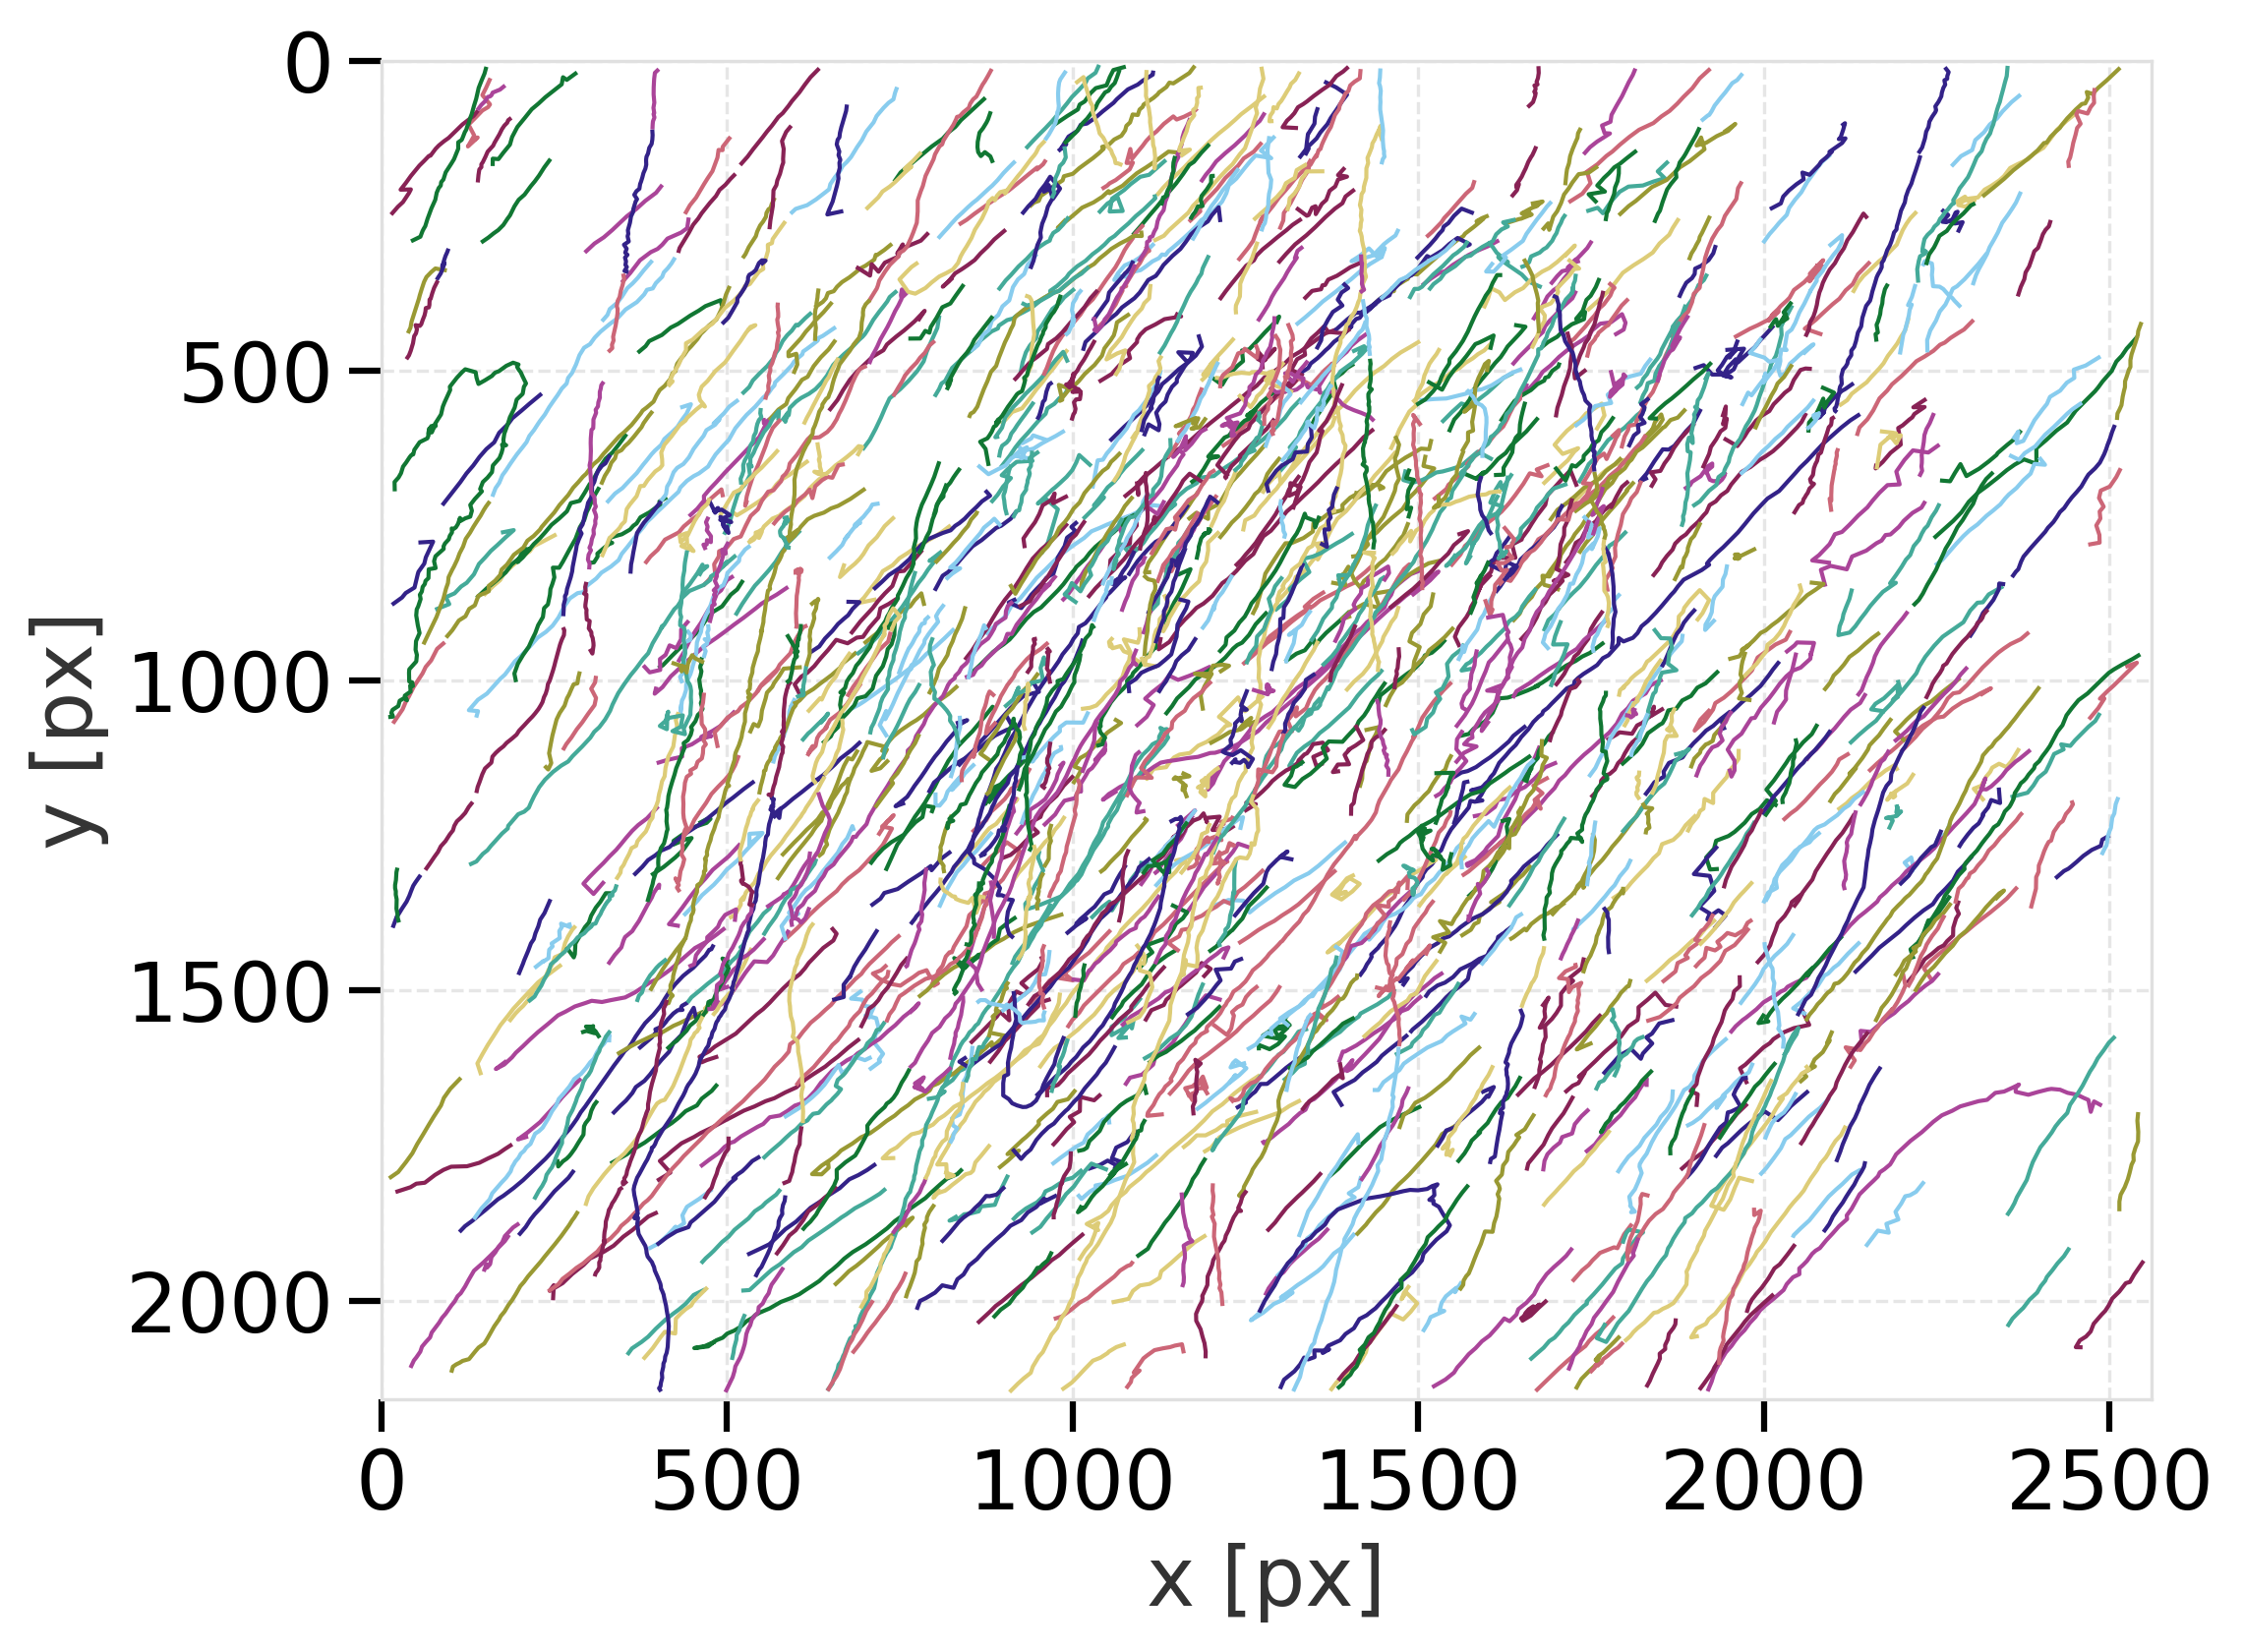

In [80]:
brownian_threshold = 1.4

imsd = tp.imsd(t1, mpp=scale, fps=1/time_interval, max_lagtime=100)

from scipy.optimize import curve_fit

def ln_pl(x, k, a):
        return k * x + np.log10(a)

def filter_trajectories(imsd_df, threshold=1.5, window=(20, 100)):
    """
    MSDのべき数(α)に基づいて軌跡をフィルタリングする
    """
    good_particle_ids = []
    
    # ログ変換用の最小値（0や負の値を防ぐ）
    # imsd_dfのindexはlag time (dt)
    log_dt = np.log10(imsd_df.index.values)
    
    # フィルタリング範囲のマスク作成
    mask = (log_dt > np.log10(window[0])) & (log_dt < np.log10(window[1]))
    fit_x = log_dt[mask]

    for particle_id in imsd_df.columns:
        msd_values = imsd_df[particle_id].values
        
        # 欠損値(NaN)を除去して有効なデータ点のみ抽出
        valid = ~np.isnan(msd_values) & mask
        if np.sum(valid) < 3:  # フィッティングに必要な最小データ点数
            continue
            
        fit_y = np.log10(msd_values[valid])
        
        try:
            # popt[0] がべき数 (alpha) に相当
            popt, _ = curve_fit(ln_pl, log_dt[valid], fit_y)
            alpha = popt[0]
            
            if alpha >= threshold:
                good_particle_ids.append(particle_id)
        except Exception as e:
            # フィッティングが収束しなかった場合などはスキップ
            continue
            
    return good_particle_ids

good_ids = filter_trajectories(imsd,threshold=brownian_threshold)
t2 = t1[t1['particle'].isin(good_ids)].copy()

plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(t2);

trajectory num: 1008


/tmp/ipykernel_2020/972020743.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

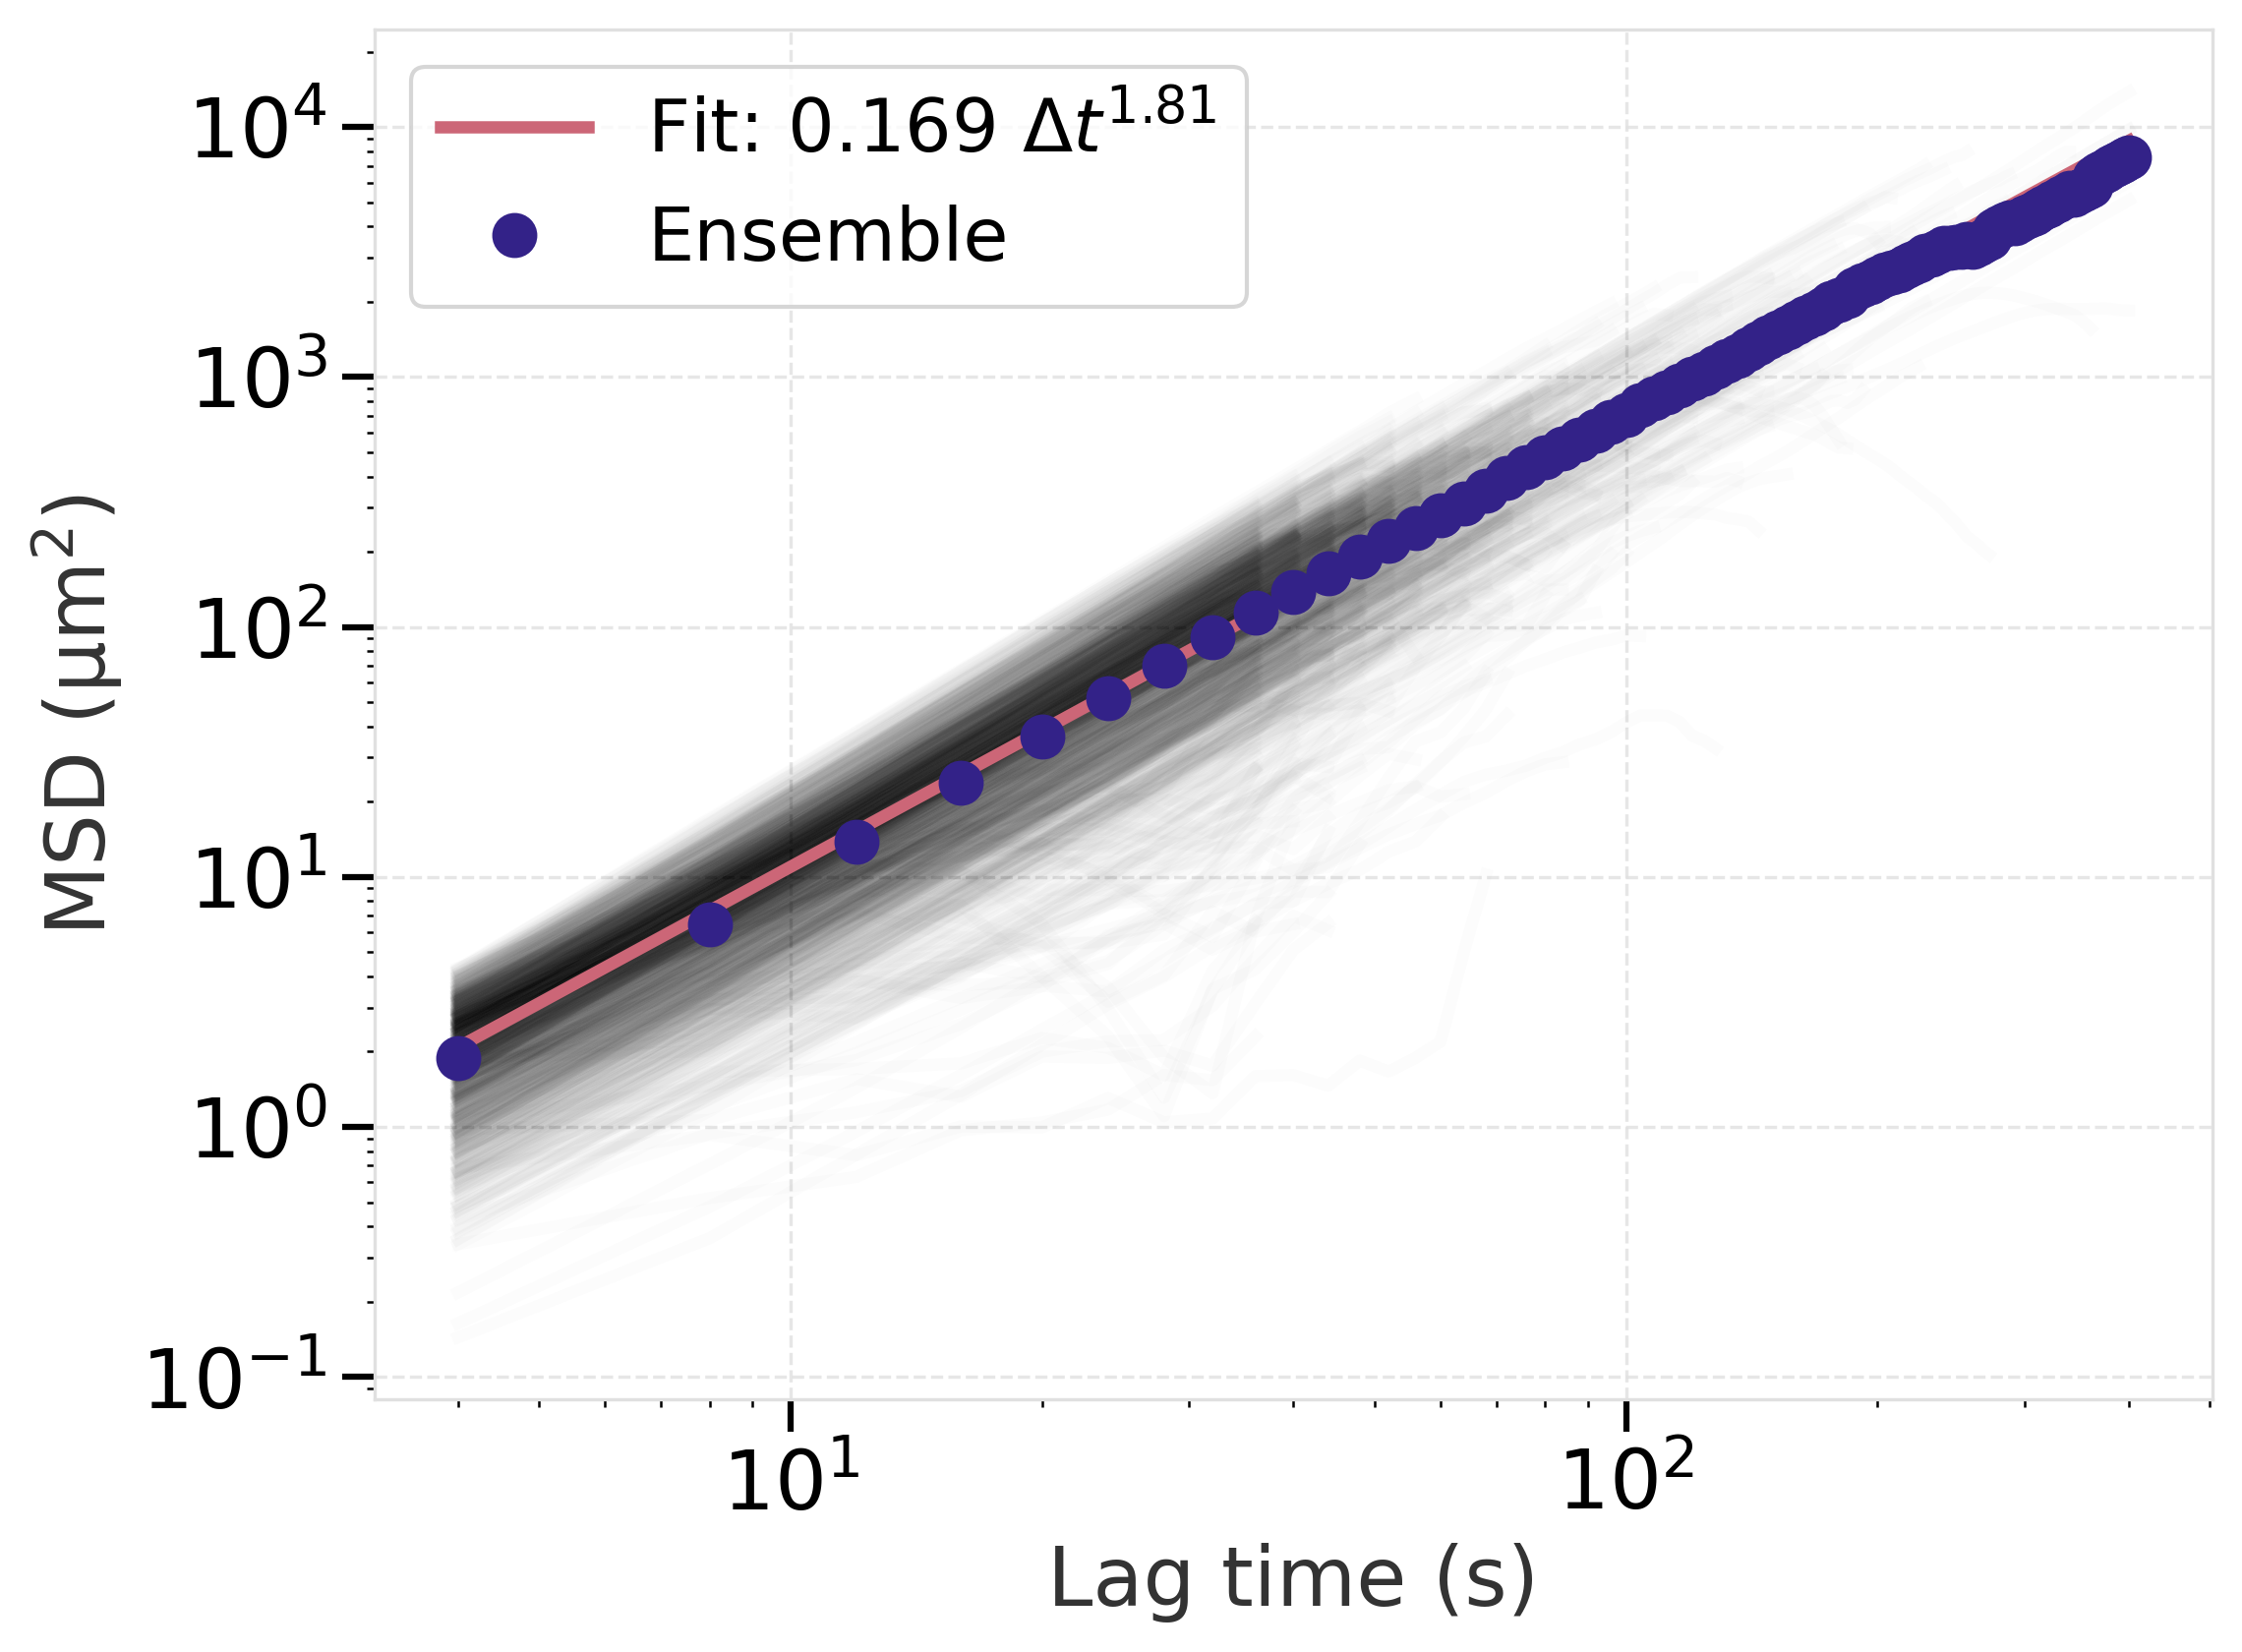

In [81]:
# MSD

from scipy.optimize import curve_fit

def power_law(x, k, a):
    return a * np.abs(x) ** k
def ln_pl(x, k, a):
        return k * x + np.log10(a)

imsd = tp.imsd(t2, mpp=scale, fps=1/time_interval, max_lagtime=100)
emsd = tp.emsd(t2, mpp=scale, fps=1/time_interval, max_lagtime=100)

print("trajectory num:",imsd.shape[1])


fig, ax = plt.subplots()
ax.plot(imsd.index, imsd, 'k-', alpha=0.01)

logx = np.log10(emsd.index.values)
logy = np.log10(emsd.values)

filter_x = np.where((logx > np.log10(20)) & (logx < np.log10(100)))

popt, pcov = curve_fit(ln_pl, logx[filter_x], logy[filter_x], p0=[0.1, 1.0])

ax.plot(emsd.index.values, power_law(emsd.index.values, *popt), label=f'Fit: {popt[1]:.3f} $\\Delta t^{{{popt[0]:.2f}}}$')

ax.plot(emsd.index, emsd, marker='o', linestyle = 'None', label='Ensemble')

ax.set_xlabel('Lag time (s)')
ax.set_ylabel('MSD (μm$^2$)')
ax.set(xscale='log', yscale='log')

ax.legend()

In [82]:
# Calculate velocity from fit (if verocity is strange, tracking has poroblem)
print(f"velocity from MSD: {np.sqrt(popt[1])} \u03bcm/s, velocity for track:{velocity} \u03bcm/s ")

velocity from MSD: 0.4107322168907903 μm/s, velocity for track:0.7 μm/s 


In [83]:
output = os.path.join(folder, 'MTtrack.csv')

# Fix frame due to time shift

t2['frame'] += TIME_SHIFT
t2.to_csv(output, index=False)

output_p = os.path.join(folder, 'MTtrack_params.txt')

with open(output_p, mode='w') as params_txt:
    params_txt.write(f"TIME_SHIFT, {TIME_SHIFT}\nminmass, {minmass}\nthreshold, {threshold}\nnoise_size, {noise_size}\nvelocity, {velocity}\nbrownian threshold, {brownian_threshold}")